11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-05-21 23:42:56.369631: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Початок навчання моделі...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8746 - loss: 0.4288 - val_accuracy: 0.9540 - val_loss: 0.1522
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9670 - loss: 0.1073 - val_accuracy: 0.9691 - val_loss: 0.0973
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9777 - loss: 0.0713 - val_accuracy: 0.9745 - val_loss: 0.0843
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9832 - loss: 0.0525 - val_accuracy: 0.9761 - val_loss: 0.0811
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9880 - loss: 0.0394 - val_accuracy: 0.9769 - val_loss: 0.0747
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0317 - val_accuracy: 0.9784 - val_loss: 0.0791
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0254 - val_accuracy: 0.9790 - val_loss: 0.0789
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accurac

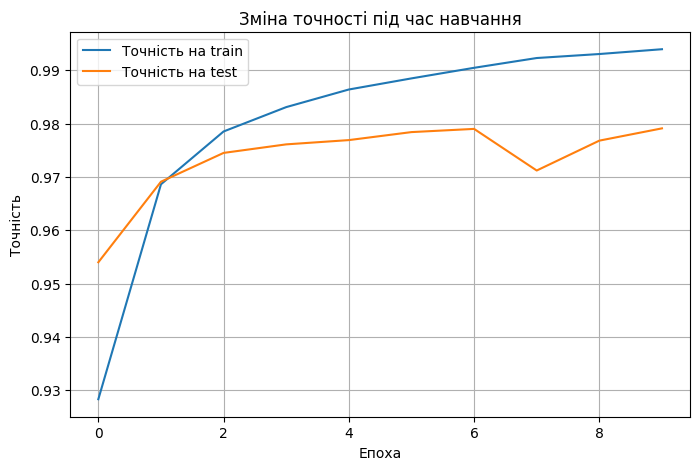

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


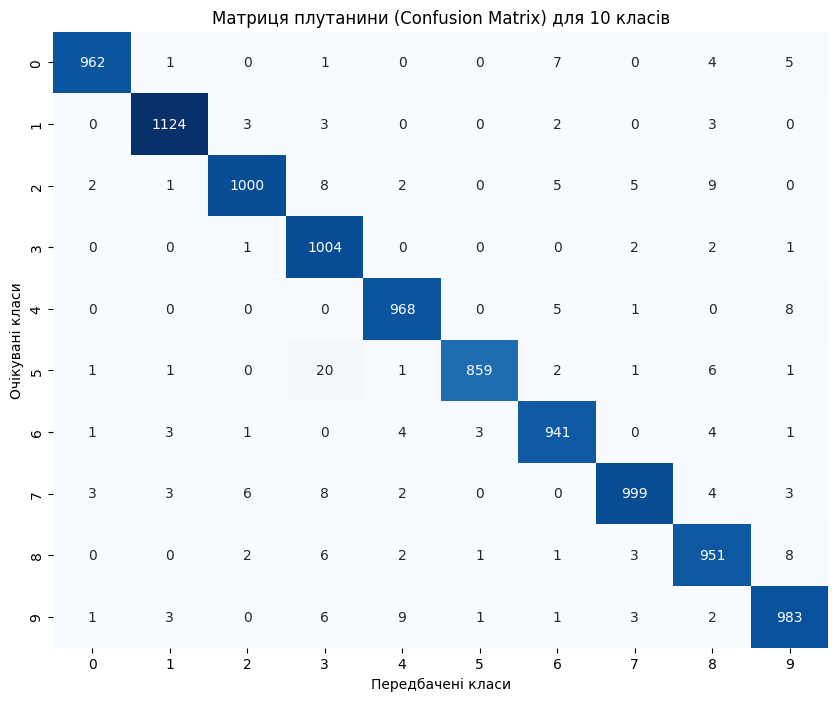


--- Звіт про класифікацію (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

           0     0.9918    0.9816    0.9867       980
           1     0.9894    0.9903    0.9899      1135
           2     0.9872    0.9690    0.9780      1032
           3     0.9508    0.9941    0.9719      1010
           4     0.9798    0.9857    0.9827       982
           5     0.9942    0.9630    0.9784       892
           6     0.9761    0.9823    0.9792       958
           7     0.9852    0.9718    0.9785      1028
           8     0.9655    0.9764    0.9709       974
           9     0.9733    0.9742    0.9737      1009

    accuracy                         0.9791     10000
   macro avg     0.9793    0.9788    0.9790     10000
weighted avg     0.9793    0.9791    0.9791     10000



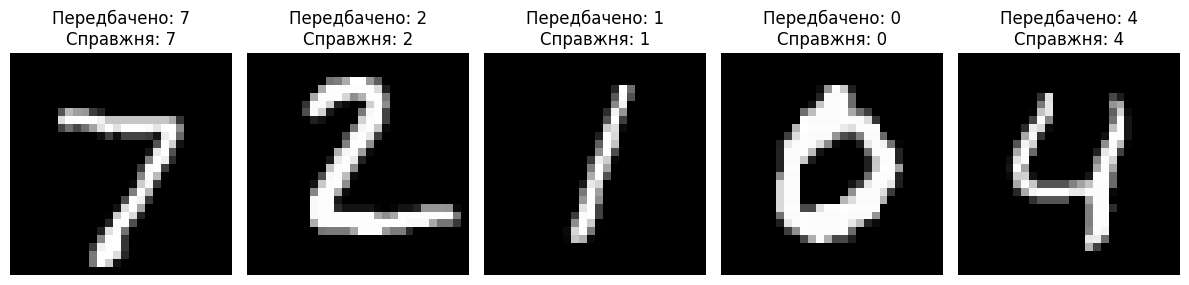

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image, ImageOps

# 1. Завантаження датасету MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Збереження оригінальних тестових міток та зображень для подальшої візуалізації
y_test_original = y_test.copy()
x_test_images = x_test.copy()

# 2. Нормалізація зображень (приведення пікселів до діапазону 0..1)
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# 3. Перетворення 28x28 зображень у вектори довжиною 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 4. Перетворення міток у формат one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 5. Створення моделі нейромережі прямого розповсюдження
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 6. Компіляція моделі
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 7. Тренування моделі
print("Початок навчання моделі...")
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

# 8. Оцінка моделі на тестових даних
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nТочність на тестових даних (Accuracy): {accuracy * 100:.2f}%")

# 9. Візуалізація графіка навчання
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Точність на train')
plt.plot(history.history['val_accuracy'], label='Точність на test')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.title('Зміна точності під час навчання')
plt.grid(True)
plt.savefig('accuracy_history_lab3.png', dpi=300)
plt.show()

# =====================================================================
# ДОДАТКОВІ ЗАВДАННЯ ЗГІДНО З ВИМОГАМИ ЛАБОРАТОРНОЇ
# =====================================================================

# Отримання передбачень для тестового набору
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 10. Побудова матриці помилок (Confusion Matrix)
cm = confusion_matrix(y_test_original, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Передбачені класи')
plt.ylabel('Очікувані класи')
plt.title('Матриця плутанини (Confusion Matrix) для 10 класів')
plt.savefig('confusion_matrix_lab3.png', dpi=300)
plt.show()

# 11. Обчислення accuracy, precision, recall та F-Score
print("\n--- Звіт про класифікацію (Precision, Recall, F1-Score) ---")
# scikit-learn автоматично розраховує мікро-, макро- та зважені оцінки
print(classification_report(y_test_original, y_pred_classes, digits=4))

# Візуалізація кількох випадкових передбачень
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test_images[i], cmap='gray')
    plt.title(f"Передбачено: {y_pred_classes[i]}\nСправжня: {y_test_original[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('predictions_sample_lab3.png', dpi=300)
plt.show()

# 12. Функція розпізнавання власноруч написаних цифр
def predict_custom_image(image_path, model):
    """
    Функція приймає шлях до зображення, обробляє його відповідно до формату MNIST
    (градієнт сірого, 28x28 пікселів, інверсія) та повертає передбачення.
    """
    try:
        # Завантаження зображення у відтінках сірого (L)
        img = Image.open(image_path).convert('L')
        
        # Увага: MNIST використовує світлі цифри на чорному тлі. 
        # Якщо ваша картинка - чорна цифра на білому папері, розкоментуйте наступний рядок:
        # img = ImageOps.invert(img)
        
        # Зміна розміру до потрібних 28x28 пікселів
        img = img.resize((28, 28))
        
        # Перетворення у масив та нормалізація (0-1)
        img_array = np.array(img).astype("float32") / 255.0
        
        # Візуалізація того, що саме «побачить» нейромережа
        plt.figure(figsize=(3, 3))
        plt.imshow(img_array, cmap='gray')
        plt.title("Оброблене зображення")
        plt.axis('off')
        plt.show()
        
        # Перетворення вектора (reshape) під вхідний шар
        img_array = img_array.reshape(1, 784)
        
        # Передбачення
        prediction = model.predict(img_array)
        predicted_digit = np.argmax(prediction)
        confidence = np.max(prediction) * 100
        
        print(f"Передбачена цифра: {predicted_digit} (Впевненість мережі: {confidence:.2f}%)")
        return predicted_digit
        
    except Exception as e:
        print(f"Помилка при обробці зображення: {e}")

# Щоб протестувати свою цифру, збережіть її як "my_digit.png" та розкоментуйте рядок нижче:
# predict_custom_image('my_digit.png', model)